# Insurance Risk Analytics - Exploratory Data Analysis

## Objective
The objective of this analysis is to explore portfolio risk,
claim behavior, customer distribution, and profitability trends
within the insurance dataset.

This analysis aims to:
- assess data quality
- identify claim and premium patterns
- evaluate profitability using loss ratio analysis
- detect outliers and anomalies
- uncover geographic and temporal trends

In [16]:
# =========================================
# PROJECT IMPORTS
# =========================================

import sys
import os

# Add project root directory
sys.path.append(os.path.abspath(".."))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
from src.data_loader import load_data
from src.data_cleaning import *
from src.eda_utils import *
from src.visualization import *

In [17]:
# Load dataset
df = load_data("../data/MachineLearningRating_v3.txt")

# Display first rows
df.columns

c:\Users\Betty\OneDrive\Desktop\ten_academy\insurance-risk-analytics\src\data_loader.py:30: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=separator)


Dataset loaded successfully: (1000098, 52)


Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='str')

In [18]:
# data summerization 
# Dataset shape
df.shape

# Data types
df.dtypes

# Descriptive statistics
descriptive_statistics(df)

# missing  value assessmnet 
# missing_value_report(df)

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [19]:
# missing values
missing_value_report(df)

,Missing Values,Percentage
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
Rebuilt,641901,64.183810
Converted,641901,64.183810
WrittenOff,641901,64.183810
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806
Gender,9536,0.953507


## Missing Value Assessment and Handling Strategy

### Key Observations
- `NumberOfVehiclesInFleet` and `CrossBorder` contain more than 99% missing values, making them unsuitable for reliable analysis and strong candidates for exclusion.
- `CustomValueEstimate` has approximately 78% missing values and may require careful consideration before use in modeling or statistical analysis.
- Vehicle-related attributes such as `VehicleType`, `make`, `Model`, and `bodytype` contain less than 0.1% missing values, which can be safely imputed or removed with minimal impact.
- Financial variables such as `TotalPremium` and `TotalClaims` contain no missing values, which is important for profitability and loss ratio analysis.

### Proposed Handling Strategy
- Columns with extremely high missingness (>70%) may be excluded due to limited analytical value.
- Numerical variables with moderate missingness may be imputed using:
  - **Median imputation** for skewed variables and outlier-prone distributions (`CustomValueEstimate`)
  - **Mean imputation** for approximately symmetric numerical variables
- Categorical variables with low missingness may be filled using:
  - Mode imputation
  - `"Unknown"` category assignment
- Rows with negligible missing values may alternatively be dropped where appropriate.

### Distribution and Outlier Considerations
Descriptive statistics indicate substantial skewness and extreme outliers in variables such as:
- `TotalClaims`
- `TotalPremium`
- `CustomValueEstimate`
- `SumInsured`

For example:
- `TotalClaims` ranges from negative adjustments to over 393,000
- `CustomValueEstimate` reaches values above 26 million
- Large gaps between median and maximum values suggest heavy-tailed distributions

Due to these characteristics, median-based imputation and robust outlier analysis techniques are more appropriate than simple mean substitution for several financial variables.

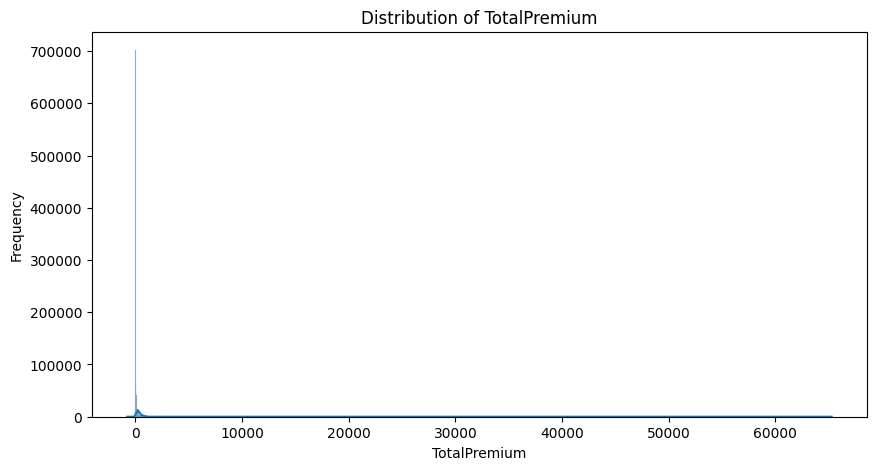

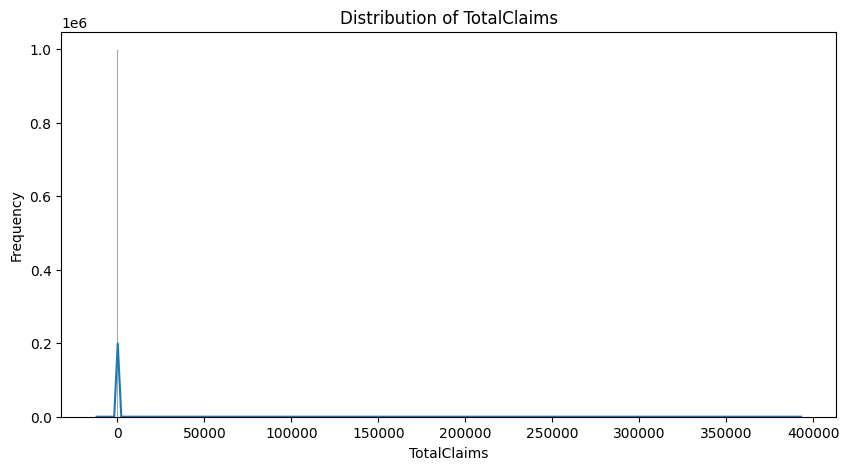

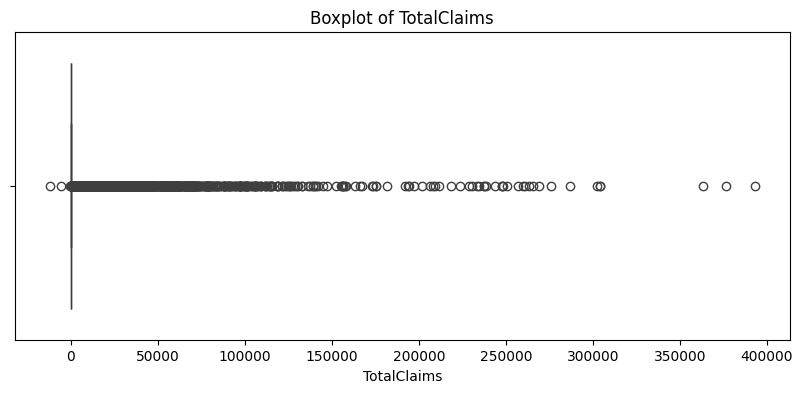

In [20]:
# univariate Analysis 
histogram_plot(df, 'TotalPremium')

histogram_plot(df, 'TotalClaims')

boxplot_plot(df, 'TotalClaims')

C:\Users\Betty\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


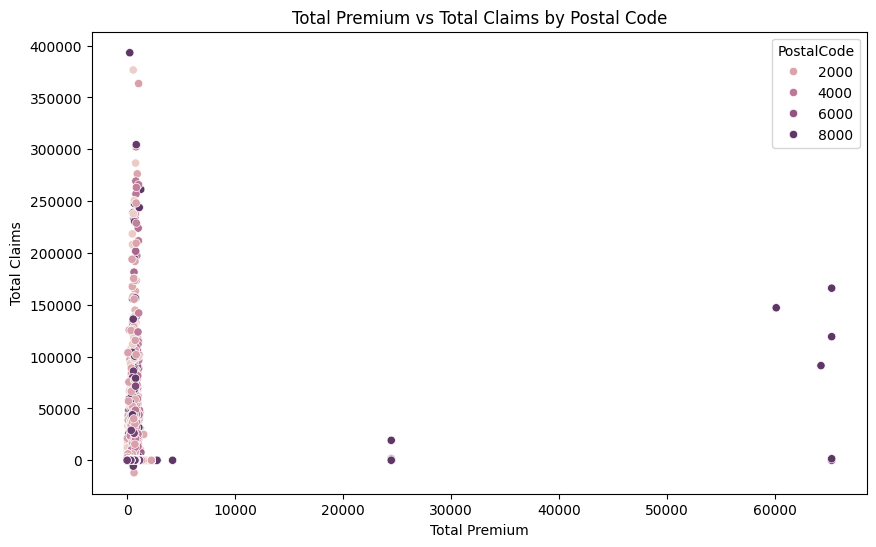

In [34]:
# Bivariate Analysis 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims',
    hue='PostalCode'
)

plt.title("Total Premium vs Total Claims by Postal Code")

plt.xlabel("Total Premium")

plt.ylabel("Total Claims")

plt.show()

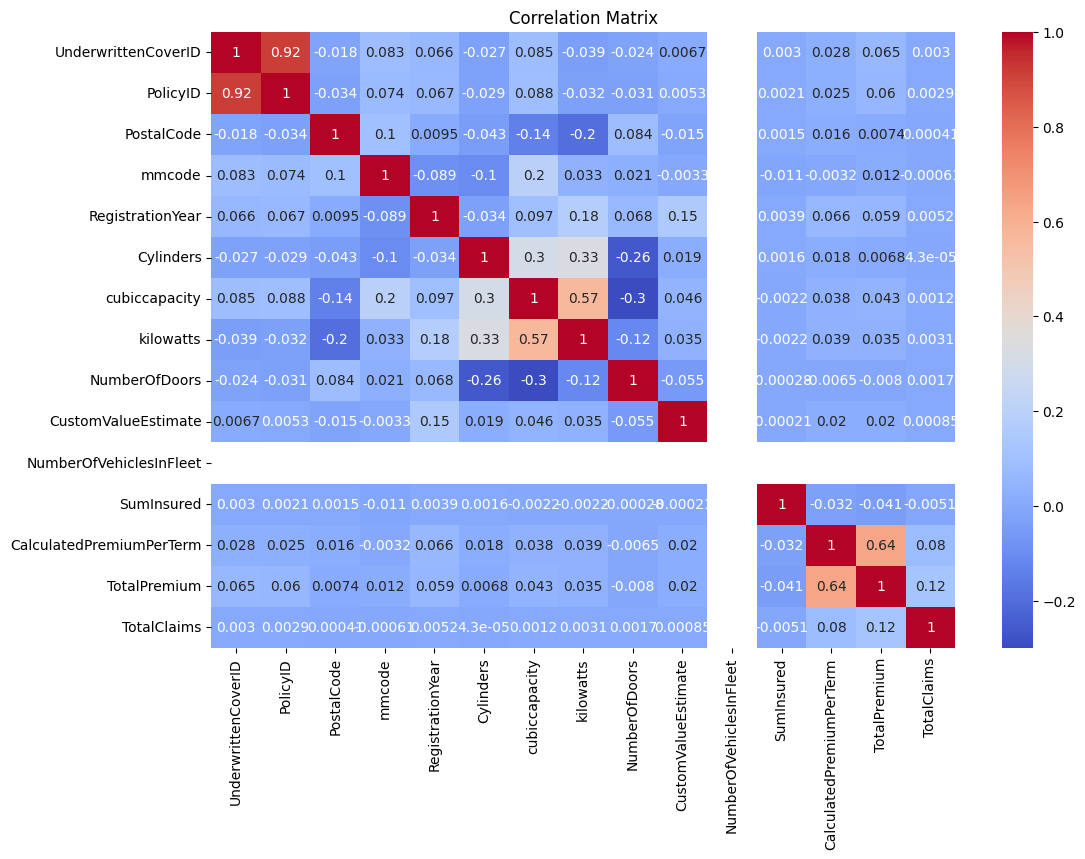

In [22]:
# Coorelation Anlayis 
numeric_cols = df.select_dtypes(include=np.number).columns

correlation_heatmap(df, numeric_cols)

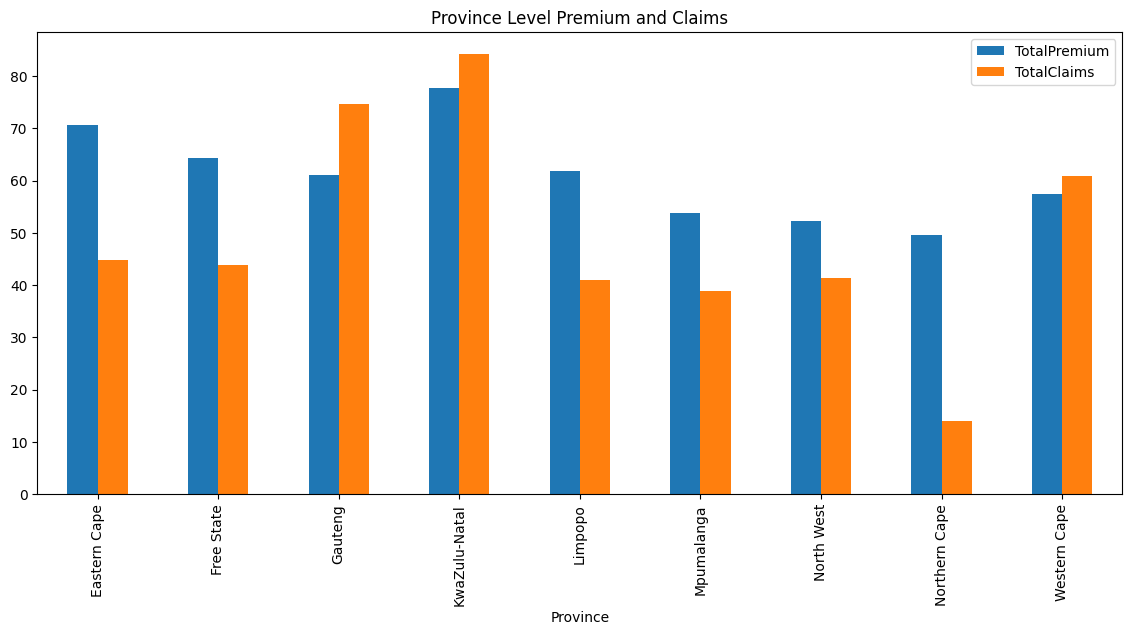

In [23]:
# geographical Trend 
province_summary = df.groupby('Province')[
    ['TotalPremium', 'TotalClaims']
].mean()

province_summary.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Province Level Premium and Claims")
plt.show()

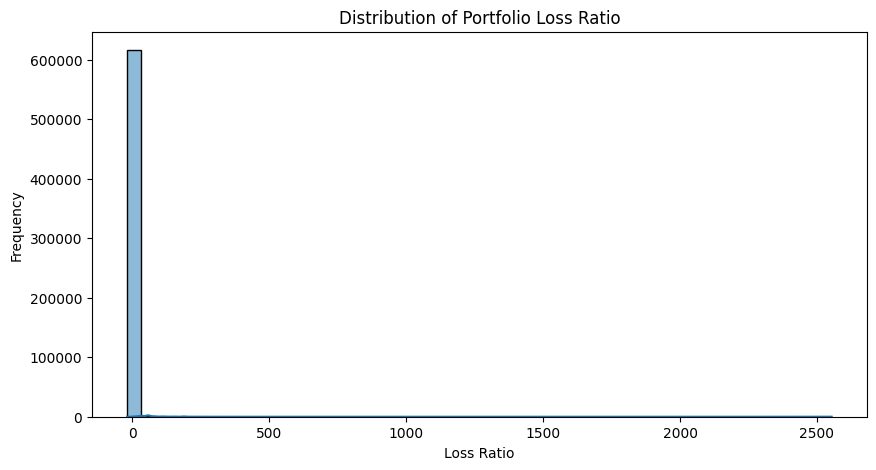

In [ ]:
# Loss Ratio Anlysis 

plt.figure(figsize=(10, 5))

sns.histplot(
    df['LossRatio'],
    bins=50,
    kde=True
)

plt.title("Distribution of Portfolio Loss Ratio")

plt.xlabel("Loss Ratio")

plt.ylabel("Frequency")

plt.show()

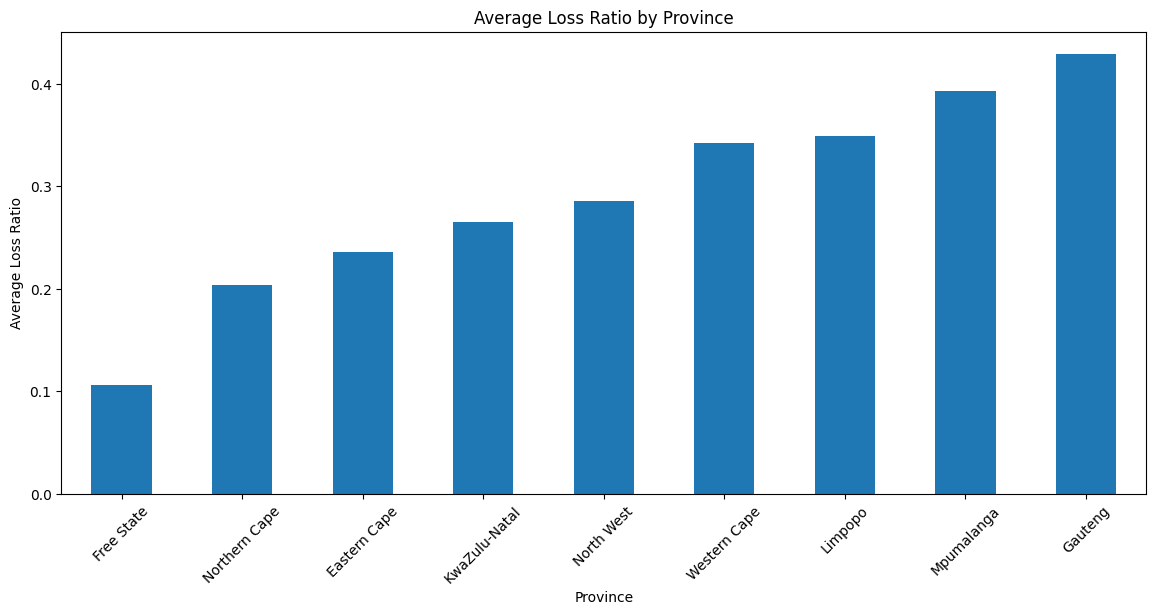

In [30]:
# Loss Ration by Province 

province_loss = df.groupby('Province')['LossRatio'].mean().sort_values()

plt.figure(figsize=(14, 6))

province_loss.plot(kind='bar')

plt.title("Average Loss Ratio by Province")

plt.xlabel("Province")

plt.ylabel("Average Loss Ratio")

plt.xticks(rotation=45)

plt.show()

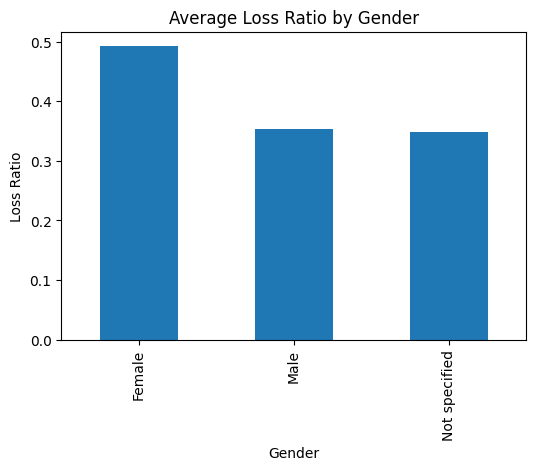

In [31]:
# Loss Ratio by Gender 
gender_loss = df.groupby('Gender')['LossRatio'].mean()

plt.figure(figsize=(6, 4))

gender_loss.plot(kind='bar')

plt.title("Average Loss Ratio by Gender")

plt.ylabel("Loss Ratio")

plt.show()

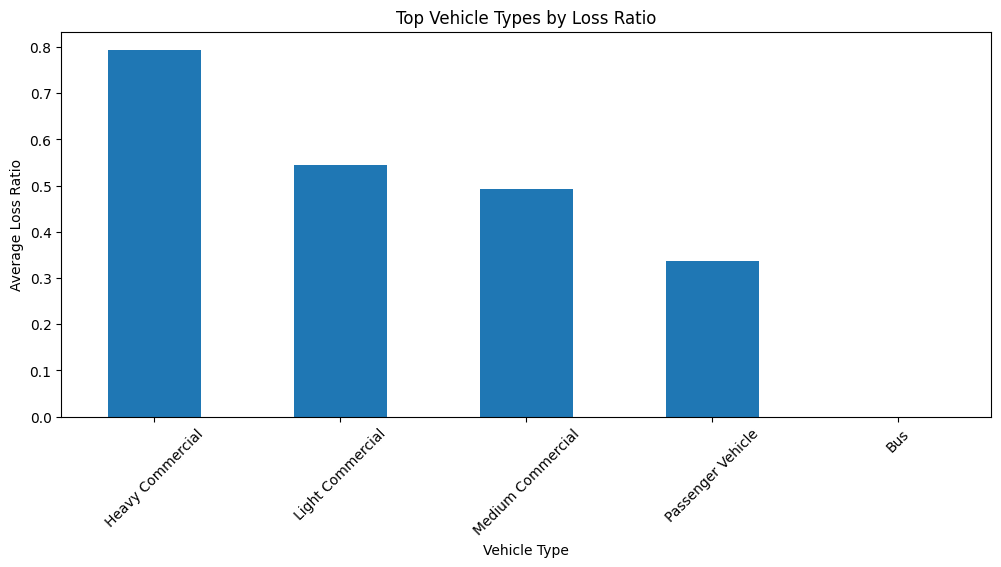

In [32]:
# Loss Ratio by Vehicle Type 
vehicle_loss = (
    df.groupby('VehicleType')['LossRatio']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))

vehicle_loss.plot(kind='bar')

plt.title("Top Vehicle Types by Loss Ratio")

plt.xlabel("Vehicle Type")

plt.ylabel("Average Loss Ratio")

plt.xticks(rotation=45)

plt.show()

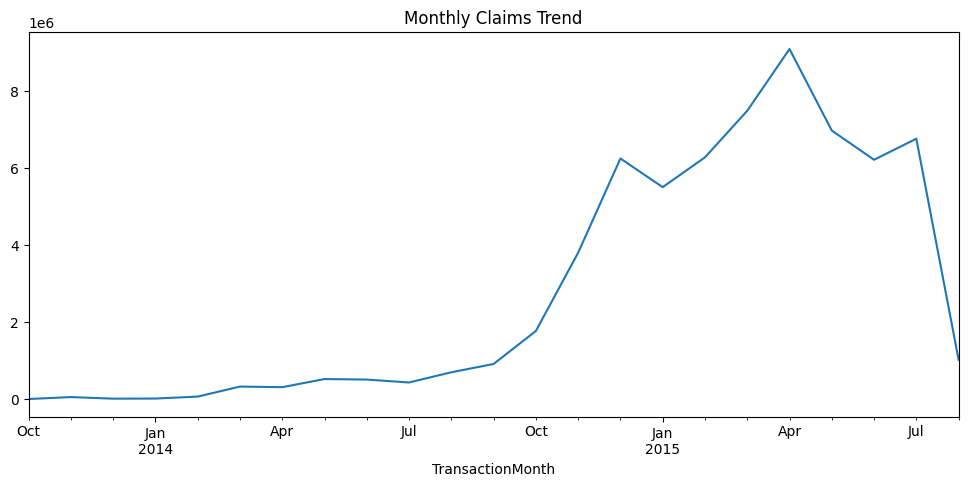

In [25]:
# Temporal Trends 
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

monthly_claims = df.groupby(
    df['TransactionMonth'].dt.to_period('M')
)['TotalClaims'].sum()

monthly_claims.plot(figsize=(12,5))

plt.title("Monthly Claims Trend")

plt.show()

In [26]:
# Vehicle Analysis 
vehicle_claims = df.groupby('make')[
    'TotalClaims'
].mean().sort_values()

vehicle_claims.tail(10)

make
IVECO                                   89.667017
BMW                                     90.558050
FIAT                                   108.625642
B.A.W                                  132.934016
POLARSUN                               134.044800
AUDI                                   137.843083
MARCOPOLO                              156.794806
HYUNDAI                                174.215195
JMC                                    191.684795
SUZUKI                                 419.634546
Name: TotalClaims, dtype: float64

## Key Insights from Univariate Analysis, Bivariate / Multivariate Analysis, Geographic Trends and Outlier Detection



